In [1]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt

path = r"C:\Users\GAMING 3\Desktop\py\Dataset.csv"
df = pd.read_csv(path)

print(df.head())

   Restaurant ID         Restaurant Name  Country Code              City  \
0        6317637        Le Petit Souffle           162       Makati City   
1        6304287        Izakaya Kikufuji           162       Makati City   
2        6300002  Heat - Edsa Shangri-La           162  Mandaluyong City   
3        6318506                    Ooma           162  Mandaluyong City   
4        6314302             Sambo Kojin           162  Mandaluyong City   

                                             Address  \
0  Third Floor, Century City Mall, Kalayaan Avenu...   
1  Little Tokyo, 2277 Chino Roces Avenue, Legaspi...   
2  Edsa Shangri-La, 1 Garden Way, Ortigas, Mandal...   
3  Third Floor, Mega Fashion Hall, SM Megamall, O...   
4  Third Floor, Mega Atrium, SM Megamall, Ortigas...   

                                     Locality  \
0   Century City Mall, Poblacion, Makati City   
1  Little Tokyo, Legaspi Village, Makati City   
2  Edsa Shangri-La, Ortigas, Mandaluyong City   
3      SM 

In [2]:
print(df['Rating text'])

0       Excellent
1       Excellent
2       Very Good
3       Excellent
4       Excellent
          ...    
9546    Very Good
9547    Very Good
9548         Good
9549    Very Good
9550    Very Good
Name: Rating text, Length: 9551, dtype: object


Task1: Restaurant Reviews


Analyze the text reviews to identify the most
common positive and negative keywords.

In [4]:
positive_data = df.loc[df['Aggregate rating'] >= 2.5]
print(positive_data)

      Restaurant ID           Restaurant Name  Country Code              City  \
0           6317637          Le Petit Souffle           162       Makati City   
1           6304287          Izakaya Kikufuji           162       Makati City   
2           6300002    Heat - Edsa Shangri-La           162  Mandaluyong City   
3           6318506                      Ooma           162  Mandaluyong City   
4           6314302               Sambo Kojin           162  Mandaluyong City   
...             ...                       ...           ...               ...   
9546        5915730               Naml? Gurme           208         ??stanbul   
9547        5908749              Ceviz A??ac?           208         ??stanbul   
9548        5915807                     Huqqa           208         ??stanbul   
9549        5916112               A???k Kahve           208         ??stanbul   
9550        5927402  Walter's Coffee Roastery           208         ??stanbul   

                           

In [5]:
positive_keywords = positive_data['Rating text'].unique()
print(positive_keywords)

['Excellent' 'Very Good' 'Good' 'Average']


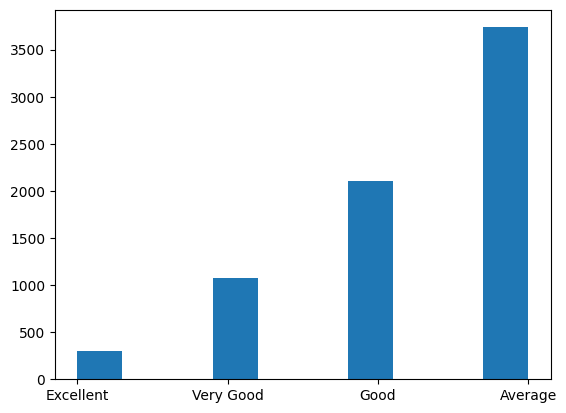

In [6]:
plt.hist(positive_data['Rating text'], label = positive_keywords)
plt.show()

In [7]:
negative_data = df.loc[(df['Aggregate rating'] < 2.5)&(df['Aggregate rating'] > 0)]
negative_keywords = negative_data['Rating text'].unique()
print(negative_keywords)

['Poor']


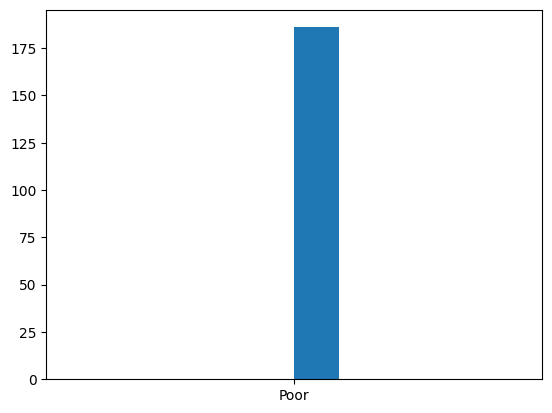

In [8]:
plt.hist(negative_data['Rating text'], label=negative_keywords)
plt.show()

Task 3: Votes Analysis


Identify the restaurants with the highest and
lowest number of votes.

In [12]:
highest_voted_resturant = df.groupby('Restaurant Name')['Votes'].sum().sort_values(ascending=False)
highest_voted_resturant = highest_voted_resturant.idxmax()
print("The Highest Voted Restaurant is : ",highest_voted_resturant)


The Highest Voted Restaurant is :  Barbeque Nation


In [13]:
lowest_voted_resturant = df.groupby('Restaurant Name')['Votes'].sum().sort_values()
lowest_voted_resturant = lowest_voted_resturant.idxmin()
print("The lowest Voted Restaurant is : ",lowest_voted_resturant)

The lowest Voted Restaurant is :  KitchenYard


Analyze if there is a correlation between the
number of votes and the rating of a
restaurant.

In [15]:
correlation = np.corrcoef(df['Votes'], df['Aggregate rating'])
correlation = np.round(correlation, 2)
print(correlation)


[[1.   0.31]
 [0.31 1.  ]]


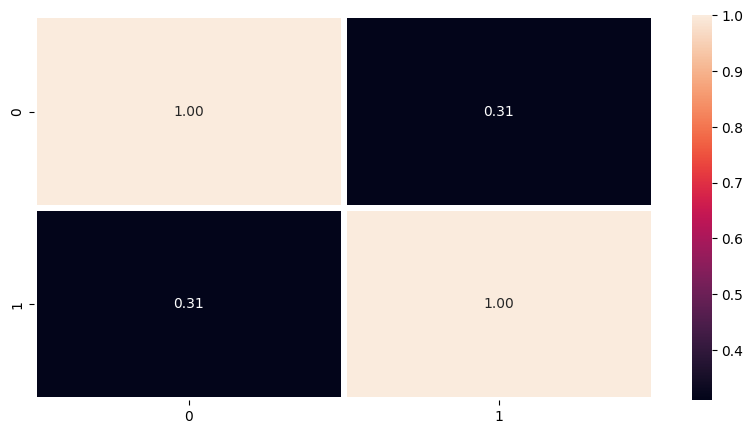

In [17]:
import seaborn as sns
plt.figure(figsize=(10, 5), dpi=100)
sns.heatmap(correlation, annot=True, fmt=".2f", linewidths=4)
plt.show()


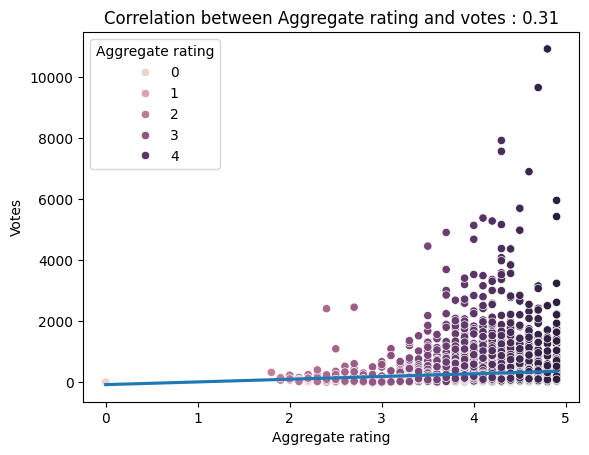

As per result correlation value = 0.31 , which indicate there is a moderate positive correlation between these two variables.


In [18]:
sns.scatterplot(data=df, y = 'Votes', hue='Aggregate rating', x = 'Aggregate rating')
sns.regplot(data=df, x='Aggregate rating', y='Votes', scatter=False)
plt.title(f'Correlation between Aggregate rating and votes : 0.31')
plt.show()
print("As per result correlation value = 0.31 , which indicate there is a moderate positive correlation between these two variables.")

Task3: Price Range vs. Online Delivery and
Table Booking


Analyze if there is a relationship between the
price range and the availability of online
delivery and table booking.

In [20]:
x1 = df['Has Online delivery']
y = df['Average Cost for two']
x2 = df['Has Table booking']

plot 1 for online delivery with the avg cost 
plot 2 for table booking with the avg cost

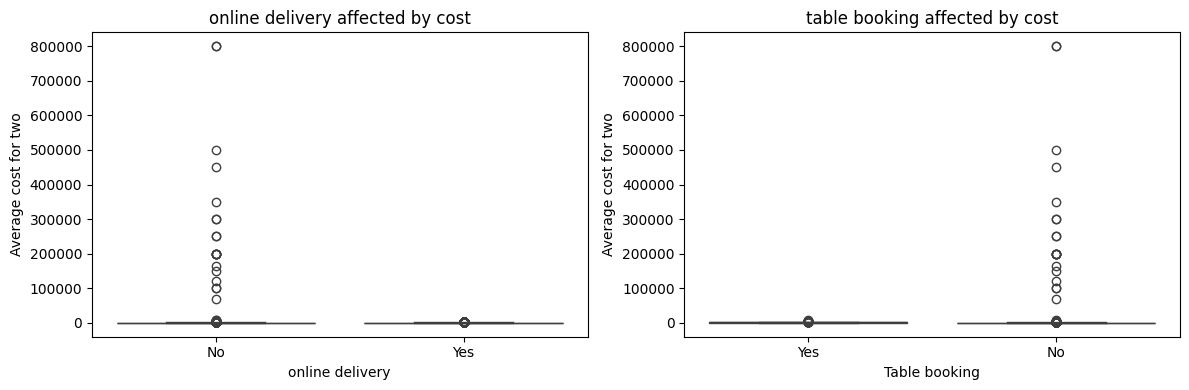

In [24]:
plt.figure(figsize=(12,4))
plt.subplot(1,2,1)
sns.boxplot(x=x1, y=y)
plt.xlabel('online delivery')
plt.ylabel('Average cost for two')
plt.title('online delivery affected by cost')
plt.subplot(1,2,2)
sns.boxplot(x=x2,y=y)
plt.xlabel('Table booking')
plt.ylabel('Average cost for two')
plt.title('table booking affected by cost')
plt.tight_layout()
plt.show()

In [25]:
print("Both the online delivery and table booking are negatively impacted by the cost")

Both the online delivery and table booking are negatively impacted by the cost


Determine if higher-priced restaurants are
more likely to offer these services.

In [26]:
print("high priced restaurants which have average cost more than 10,000 did not provide online delivery as well as table booking facilities")

high priced restaurants which have average cost more than 10,000 did not provide online delivery as well as table booking facilities


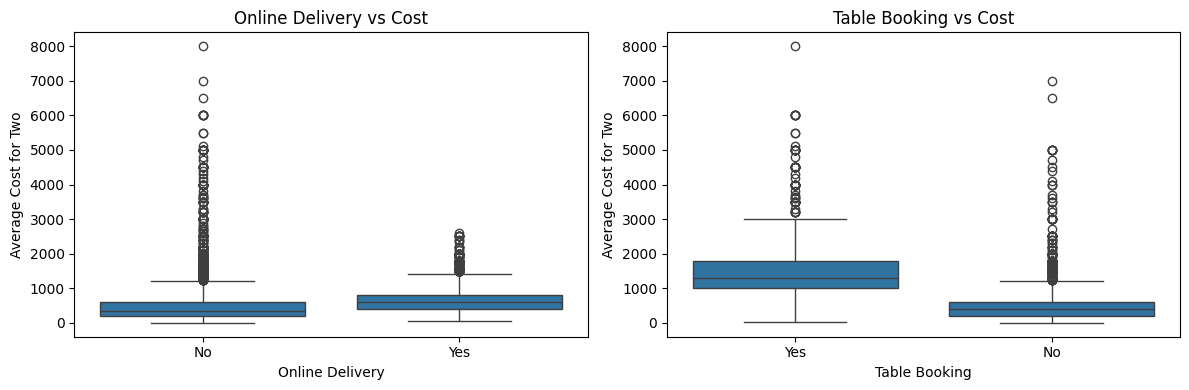

In [ ]:
import seaborn as sns

plt.figure(figsize=(12, 4))

# Plot 1: Online delivery vs cost
plt.subplot(1, 2, 1)
sns.boxplot(
    x='Has Online delivery',
    y='Average Cost for two',
    data=df[df['Average Cost for two'] < 10000]
)
plt.title('Online Delivery vs Cost')
plt.xlabel('Online Delivery')
plt.ylabel('Average Cost for Two')

# Plot 2: Table booking vs cost
plt.subplot(1, 2, 2)
sns.boxplot(
    x='Has Table booking',
    y='Average Cost for two',
    data=df[df['Average Cost for two'] < 10000]
)
plt.title('Table Booking vs Cost')
plt.xlabel('Table Booking')
plt.ylabel('Average Cost for Two')

plt.tight_layout()
plt.show()



In [34]:
print("The online delivery facility is persent for only those restaurant , where the avg cost is less than 1000. ")
print("The table booking facility is avalible in restaurant with an average cost ranging from 1000 to 2000. ")

The online delivery facility is persent for only those restaurant , where the avg cost is less than 1000. 
The table booking facility is avalible in restaurant with an average cost ranging from 1000 to 2000. 
